# Sparkle Movie

## Introduction

Bienvenue dans ce notebook dédié à mon projet de recommandation de films pour une plateforme de streaming vidéo, utilisant le dataset MovieLens et l'outil de traitement distribué Spark MLlib. L'objectif principal de ce projet est d'améliorer l'expérience utilisateur en proposant des recommandations personnalisées, basées à la fois sur le contenu des films et les préférences des utilisateurs.

<u>Objectifs du Projet</u> :  
1. Chargement et Exploration des Données : Nous débuterons par importer et explorer les données à l'aide de Spark, en analysant les tendances générales telles que les films les mieux notés et les genres les plus populaires.

2. Modélisation avec Spark MLlib - ALS : Nous utiliserons l'algorithme ALS (Alternating Least Squares) pour entraîner un modèle de recommandation collaborative. Nous ajusterons les hyperparamètres et évaluerons la performance du modèle à l'aide de la RMSE (Root Mean Square Error).

3. Recommandation Basée sur le Contenu : Nous créerons des profils de films basés sur leurs genres, puis implémenterons un système recommandant des films similaires à ceux aimés par un utilisateur, en utilisant TF-IDF et la similarité cosinus.

4. Recommandation Basée sur les Proximités Utilisateurs (KNN) : Nous mettrons en œuvre une approche KNN pour trouver des utilisateurs similaires et générer des recommandations basées sur leurs évaluations.

5. Évaluation des Approches de Recommandation : Nous évaluerons la précision et la couverture de nos recommandations, comparerons les résultats des différentes approches, et conclurons sur la performance globale de notre modèle.

Ce notebook sera structuré de manière à guider à travers chaque étape du processus, depuis l'exploration initiale des données jusqu'à l'évaluation finale de nos méthodes de recommandation. N'hésitez pas à suivre chaque section et à explorer les détails pour une compréhension approfondie du développement de notre outil de recommandation.

### Imports

In [3]:
# =========================
# Imports (Spark-first)
# =========================

import os
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import setuptools
import distutils
print("setuptools:", setuptools.__version__)
print("distutils module:", distutils.__file__)

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

from pyspark.ml.feature import Tokenizer, HashingTF, IDF
from pyspark.ml import Pipeline

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

setuptools: 82.0.0
distutils module: c:\wamp64\www\Sparkle_Movie2\env\Lib\site-packages\setuptools\_distutils\__init__.py


In [4]:
os.environ["HADOOP_HOME"] = os.path.abspath("hadoop")
os.environ["hadoop.home.dir"] = os.environ["HADOOP_HOME"]

print("HADOOP_HOME =", os.environ["HADOOP_HOME"])

HADOOP_HOME = c:\wamp64\www\Sparkle_Movie2\hadoop


### 1. Préparation de l'environnement

In [5]:
import os, sys, subprocess

print("Python:", sys.executable)
print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("SPARK_HOME (before):", os.environ.get("SPARK_HOME"))

# IMPORTANT : on neutralise le Spark externe foireux
os.environ.pop("SPARK_HOME", None)
os.environ.pop("PYSPARK_SUBMIT_ARGS", None)

# Force Spark à utiliser le Python du venv
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

print("SPARK_HOME (after):", os.environ.get("SPARK_HOME"))

# Sanity check Java
try:
    out = subprocess.check_output(["java", "-version"], stderr=subprocess.STDOUT, text=True)
    print(out.splitlines()[0])
except Exception as e:
    print("java -version failed:", e)

Python: c:\wamp64\www\Sparkle_Movie2\env\Scripts\python.exe
JAVA_HOME: C:\Program Files\Eclipse Adoptium\jdk-11.0.26.4-hotspot
SPARK_HOME (before): C:\Program Files (x86)\spark-3.5.5-bin-hadoop3\spark-3.5.5-bin-hadoop3
SPARK_HOME (after): None
openjdk version "11.0.26" 2025-01-21


In [ ]:
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (
    SparkSession.builder
    .appName("MovieRecommendation")
    .master("local[*]")  
    .config("spark.sql.shuffle.partitions", "8") 
    .config("spark.driver.memory", "4g") 
    .getOrCreate()
)

print("Spark version:", spark.version)
spark.range(5).show()

Spark version: 3.5.1
+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
+---+



J'ai ensuite récupéré un dataset sur le site: https://grouplens.org/datasets/movielens/

### 2. Chargement et exploration des données

Je vais maintenant importer les fichiers CSV nécessaires pour réaliser ce projet, à savoir:  
- ratings.csv  
- movies.csv  

Et les mettre dans des Dataframes Spark.

In [7]:
# =========================
# Chargement des données (Spark DataFrames)
# =========================

ratings_df = spark.read.csv("data/ml-latest-small/ratings.csv", header=True, inferSchema=True)
movies_df  = spark.read.csv("data/ml-latest-small/movies.csv", header=True, inferSchema=True)

# Vérifs demandées : schémas + head(10)
print("=== ratings_df schema ===")
ratings_df.printSchema()
ratings_df.show(10, truncate=False)

print("=== movies_df schema ===")
movies_df.printSchema()
movies_df.show(10, truncate=False)

# Nettoyage basique (souvent attendu)
ratings_df = ratings_df.dropna().dropDuplicates(["userId", "movieId", "timestamp"])
movies_df  = movies_df.dropna().dropDuplicates(["movieId"])

print("Counts after cleaning:")
print("ratings_df:", ratings_df.count())
print("movies_df :", movies_df.count())

=== ratings_df schema ===
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|
|1     |3      |4.0   |964981247|
|1     |6      |4.0   |964982224|
|1     |47     |5.0   |964983815|
|1     |50     |5.0   |964982931|
|1     |70     |3.0   |964982400|
|1     |101    |5.0   |964980868|
|1     |110    |4.0   |964982176|
|1     |151    |5.0   |964984041|
|1     |157    |5.0   |964984100|
+------+-------+------+---------+
only showing top 10 rows

=== movies_df schema ===
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                      

In [8]:
# Contrôles rapides sur les colonnes clés
ratings_df.select(
    F.count("*").alias("rows"),
    F.countDistinct("userId").alias("n_users"),
    F.countDistinct("movieId").alias("n_movies"),
    F.min("rating").alias("min_rating"),
    F.max("rating").alias("max_rating"),
).show()

movies_df.select(
    F.count("*").alias("rows"),
    F.countDistinct("movieId").alias("n_movies"),
).show()

+------+-------+--------+----------+----------+
|  rows|n_users|n_movies|min_rating|max_rating|
+------+-------+--------+----------+----------+
|100836|    610|    9724|       0.5|       5.0|
+------+-------+--------+----------+----------+

+----+--------+
|rows|n_movies|
+----+--------+
|9742|    9742|
+----+--------+



In [9]:
# =========================
# Top films avec seuil minimum de notes
# =========================

min_ratings_threshold = 50  # ajustable

movie_stats = (
    ratings_df
    .groupBy("movieId")
    .agg(
        F.count("*").alias("n_ratings"),
        F.avg("rating").alias("avg_rating")
    )
    .filter(F.col("n_ratings") >= min_ratings_threshold)
)

top_movies = (
    movie_stats
    .join(movies_df, "movieId")
    .orderBy(F.col("avg_rating").desc(), F.col("n_ratings").desc())
)

top_movies.select("title", "avg_rating", "n_ratings").show(20, truncate=False)

+------------------------------------------------------------------------------+------------------+---------+
|title                                                                         |avg_rating        |n_ratings|
+------------------------------------------------------------------------------+------------------+---------+
|Shawshank Redemption, The (1994)                                              |4.429022082018927 |317      |
|Godfather, The (1972)                                                         |4.2890625         |192      |
|Fight Club (1999)                                                             |4.272935779816514 |218      |
|Cool Hand Luke (1967)                                                         |4.271929824561403 |57       |
|Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)   |4.268041237113402 |97       |
|Rear Window (1954)                                                            |4.261904761904762 |84       |
|Godfather

In [10]:
# =========================
# Films les plus notés (popularité)
# =========================

most_rated = (
    ratings_df
    .groupBy("movieId")
    .count()
    .join(movies_df, "movieId")
    .orderBy(F.col("count").desc())
)

most_rated.select("title", "count").show(20, truncate=False)

+------------------------------------------------------------------------------+-----+
|title                                                                         |count|
+------------------------------------------------------------------------------+-----+
|Forrest Gump (1994)                                                           |329  |
|Shawshank Redemption, The (1994)                                              |317  |
|Pulp Fiction (1994)                                                           |307  |
|Silence of the Lambs, The (1991)                                              |279  |
|Matrix, The (1999)                                                            |278  |
|Star Wars: Episode IV - A New Hope (1977)                                     |251  |
|Jurassic Park (1993)                                                          |238  |
|Braveheart (1995)                                                             |237  |
|Terminator 2: Judgment Day (1991)         

In [11]:
# =========================
# Analyse des genres
# =========================

genres_stats = (
    ratings_df
    .join(movies_df, "movieId")
    .withColumn("genre", F.explode(F.split(F.col("genres"), "\\|")))
    .groupBy("genre")
    .agg(
        F.count("*").alias("n_ratings"),
        F.avg("rating").alias("avg_rating")
    )
    .orderBy(F.col("n_ratings").desc())
)

genres_stats.show(30, truncate=False)

+------------------+---------+------------------+
|genre             |n_ratings|avg_rating        |
+------------------+---------+------------------+
|Drama             |41928    |3.6561844113718758|
|Comedy            |39053    |3.3847207640898267|
|Action            |30635    |3.447984331646809 |
|Thriller          |26452    |3.4937055799183425|
|Adventure         |24161    |3.5086089151939075|
|Romance           |18124    |3.5065107040388437|
|Sci-Fi            |17243    |3.455721162210752 |
|Crime             |16681    |3.658293867274144 |
|Fantasy           |11834    |3.4910005070136894|
|Children          |9208     |3.412956125108601 |
|Mystery           |7674     |3.632460255407871 |
|Horror            |7291     |3.258195034974626 |
|Animation         |6988     |3.6299370349170004|
|War               |4859     |3.8082938876312   |
|IMAX              |4145     |3.618335343787696 |
|Musical           |4138     |3.5636781053649105|
|Western           |1930     |3.583937823834197 |


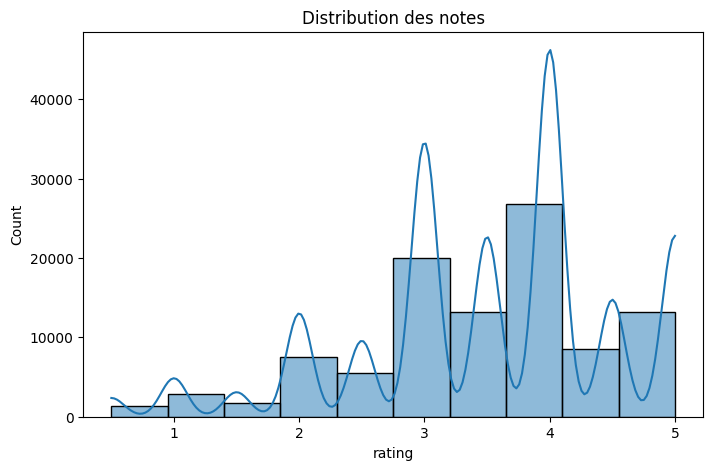

In [12]:
# =========================
# Visualisation distribution des notes
# =========================

ratings_pd = ratings_df.select("rating").toPandas()

plt.figure(figsize=(8,5))
sns.histplot(ratings_pd["rating"], bins=10, kde=True)
plt.title("Distribution des notes")
plt.show()

In [13]:
# =========================
# Evolution des notes par année
# =========================

ratings_with_year = ratings_df.withColumn(
    "year",
    F.year(F.from_unixtime("timestamp"))
)

ratings_by_year = (
    ratings_with_year
    .groupBy("year")
    .agg(F.count("*").alias("n_ratings"))
    .orderBy("year")
)

ratings_by_year.show()

+----+---------+
|year|n_ratings|
+----+---------+
|1996|     6040|
|1997|     1916|
|1998|      507|
|1999|     2439|
|2000|    10061|
|2001|     3922|
|2002|     3478|
|2003|     4014|
|2004|     3279|
|2005|     5813|
|2006|     4059|
|2007|     7114|
|2008|     4351|
|2009|     4158|
|2010|     2301|
|2011|     1690|
|2012|     4656|
|2013|     1664|
|2014|     1439|
|2015|     6616|
+----+---------+
only showing top 20 rows



In [14]:
# =========================
# Split train / validation / test
# =========================

train_df, val_df, test_df = ratings_df.randomSplit([0.8, 0.1, 0.1], seed=42)

print("Total:", ratings_df.count())
print("Train:", train_df.count())
print("Val  :", val_df.count())
print("Test :", test_df.count())

Total: 100836
Train: 80578
Val  : 10095
Test : 10163


In [15]:
# =========================
# Evaluator RMSE
# =========================

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

In [16]:
from pyspark.ml.recommendation import ALS

def train_eval_als(rank, regParam, maxIter):
    als = ALS(
        userCol="userId",
        itemCol="movieId",
        ratingCol="rating",
        coldStartStrategy="drop",   # drop NaN preds
        nonnegative=True,
        rank=rank,
        regParam=regParam,
        maxIter=maxIter,
        seed=42
    )

    model = als.fit(train_df)

    preds = model.transform(val_df).select("userId","movieId","rating","prediction")

    # Sécurités (évite evaluate() qui plante)
    preds = preds.dropna(subset=["prediction", "rating"])
    n_preds = preds.count()

    if n_preds == 0:
        # Aucun couple user-item de val n'a pu être prédit (cold-start sur val)
        return model, float("inf")

    rmse = evaluator.evaluate(preds)
    return model, rmse

In [17]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

In [ ]:
ratings_df = ratings_df.select(
    F.col("userId").cast("int").alias("userId"),
    F.col("movieId").cast("int").alias("movieId"),
    F.col("rating").cast("double").alias("rating"),
    F.col("timestamp").cast("long").alias("timestamp"),
)

train_df = train_df.cache()
val_df = val_df.cache()

train_df.count(); val_df.count()

10049

In [19]:
# =========================
# Grid search manuel
# =========================

param_grid = {
    "rank": [10, 20, 50],
    "regParam": [0.01, 0.05, 0.1],
    "maxIter": [10, 15]
}

results = []
best_model = None
best_rmse = float("inf")
best_params = None

for r in param_grid["rank"]:
    for reg in param_grid["regParam"]:
        for it in param_grid["maxIter"]:
            try:
                model, rmse = train_eval_als(rank=r, regParam=reg, maxIter=it)
                results.append((r, reg, it, rmse))
                print(f"rank={r}, regParam={reg}, maxIter={it} -> RMSE(val)={rmse:.4f}")
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_model = model
                    best_params = (r, reg, it)
            except Exception as e:
                print(f"❌ FAILED rank={r}, regParam={reg}, maxIter={it} -> {repr(e)}")

print("\n✅ Best params:", best_params)
print("✅ Best RMSE (val):", best_rmse)

rank=10, regParam=0.01, maxIter=10 -> RMSE(val)=1.0186
rank=10, regParam=0.01, maxIter=15 -> RMSE(val)=1.0322
rank=10, regParam=0.05, maxIter=10 -> RMSE(val)=0.9242
rank=10, regParam=0.05, maxIter=15 -> RMSE(val)=0.9243
rank=10, regParam=0.1, maxIter=10 -> RMSE(val)=0.8856
rank=10, regParam=0.1, maxIter=15 -> RMSE(val)=0.8852
rank=20, regParam=0.01, maxIter=10 -> RMSE(val)=1.0863
rank=20, regParam=0.01, maxIter=15 -> RMSE(val)=1.1033
rank=20, regParam=0.05, maxIter=10 -> RMSE(val)=0.9361
rank=20, regParam=0.05, maxIter=15 -> RMSE(val)=0.9361
rank=20, regParam=0.1, maxIter=10 -> RMSE(val)=0.8855
rank=20, regParam=0.1, maxIter=15 -> RMSE(val)=0.8838
rank=50, regParam=0.01, maxIter=10 -> RMSE(val)=1.1458
rank=50, regParam=0.01, maxIter=15 -> RMSE(val)=1.1681
rank=50, regParam=0.05, maxIter=10 -> RMSE(val)=0.9373
rank=50, regParam=0.05, maxIter=15 -> RMSE(val)=0.9328
rank=50, regParam=0.1, maxIter=10 -> RMSE(val)=0.8815
rank=50, regParam=0.1, maxIter=15 -> RMSE(val)=0.8820

✅ Best params: 

In [20]:
# =========================
# Evaluation finale sur test
# =========================

test_preds = best_model.transform(test_df)
test_rmse = evaluator.evaluate(test_preds)

print("📌 RMSE(test) =", test_rmse)

📌 RMSE(test) = 0.5875596259290389


In [21]:
# =========================
# Recommandations pour 5 utilisateurs
# =========================

users_subset = ratings_df.select("userId").distinct().orderBy("userId").limit(5)
users_list = [r["userId"] for r in users_subset.collect()]
print("Users choisis:", users_list)

recs = best_model.recommendForUserSubset(users_subset, 10)

recs_flat = (
    recs
    .withColumn("rec", F.explode("recommendations"))
    .select(
        "userId",
        F.col("rec.movieId").alias("movieId"),
        F.col("rec.rating").alias("pred_rating")
    )
    .join(movies_df, "movieId", "left")
    .orderBy("userId", F.col("pred_rating").desc())
)

recs_flat.show(200, truncate=False)

Users choisis: [1, 2, 3, 4, 5]
+-------+------+-----------+------------------------------------------------------------------------+------------------------------------------+
|movieId|userId|pred_rating|title                                                                   |genres                                    |
+-------+------+-----------+------------------------------------------------------------------------+------------------------------------------+
|171495 |1     |5.449951   |Cosmos                                                                  |(no genres listed)                        |
|78836  |1     |5.4169407  |Enter the Void (2009)                                                   |Drama                                     |
|33649  |1     |5.396942   |Saving Face (2004)                                                      |Comedy|Drama|Romance                      |
|3379   |1     |5.388692   |On the Beach (1959)                                                    

In [22]:
# =========================
# Contenu : préparation du texte (title + genres)
# =========================

movies_text_df = movies_df.withColumn(
    "doc",
    F.concat_ws(" ", F.col("title"), F.regexp_replace(F.col("genres"), "\\|", " "))
)

movies_text_df.select("movieId", "title", "genres", "doc").show(5, truncate=False)

+-------+----------------------------------+-------------------------------------------+------------------------------------------------------------+
|movieId|title                             |genres                                     |doc                                                         |
+-------+----------------------------------+-------------------------------------------+------------------------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|Toy Story (1995) Adventure Animation Children Comedy Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |Jumanji (1995) Adventure Children Fantasy                   |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |Grumpier Old Men (1995) Comedy Romance                      |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |Waiting to E

In [23]:
tokenizer = Tokenizer(inputCol="doc", outputCol="words")
hashingTF = HashingTF(inputCol="words", outputCol="rawFeatures", numFeatures=2**12)
idf = IDF(inputCol="rawFeatures", outputCol="features")

content_pipeline = Pipeline(stages=[tokenizer, hashingTF, idf])
content_model = content_pipeline.fit(movies_text_df)

movies_features_df = content_model.transform(movies_text_df).select("movieId", "title", "genres", "features")
movies_features_df.show(5, truncate=False)

+-------+----------------------------------+-------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|movieId|title                             |genres                                     |features                                                                                                                                                                                            |
+-------+----------------------------------+-------------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|(4096,[517,945,1175,2233,2289,3059,3117,3656],[6.69939

In [ ]:
def get_similar_movies(movie_id: int, top_n: int = 10):
    # récupère vecteur cible
    target_row = movies_features_df.filter(F.col("movieId") == movie_id).select("features").collect()
    if not target_row:
        raise ValueError(f"movieId {movie_id} introuvable")

    target_vec = target_row[0]["features"]

    # on récupère toutes les features (dataset petit, OK)
    rows = movies_features_df.select("movieId", "title", "genres", "features").collect()

    def cos_sim(v1, v2):
        dot = float(v1.dot(v2))
        n1 = float(v1.norm(2))
        n2 = float(v2.norm(2))
        return dot / (n1 * n2) if n1 > 0 and n2 > 0 else 0.0

    scored = []
    for r in rows:
        sim = cos_sim(target_vec, r["features"])
        scored.append((r["movieId"], r["title"], r["genres"], sim))

    scored.sort(key=lambda x: x[3], reverse=True)

    scored = [s for s in scored if s[0] != movie_id]
    return scored[:top_n]

similar = get_similar_movies(1, top_n=10)
for mid, title, genres, sim in similar:
    print(f"{sim:.3f} | {mid} | {title} | {genres}")

AttributeError: module 'numpy' has no attribute 'in1d'

In [ ]:
# =========================
# KNN item-based (sklearn) + affichage en pandas (stable)
# =========================

import math
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# 1) On limite aux films assez notés (plus pertinent)
min_item_ratings = 50

popular_items = (
    ratings_df.groupBy("movieId").count()
    .filter(F.col("count") >= min_item_ratings)
    .select("movieId")
)

ratings_pop = ratings_df.join(popular_items, "movieId")

# 2) Pivot local : movieId x userId
ratings_pop_pd = ratings_pop.select("userId", "movieId", "rating").toPandas()
item_user = ratings_pop_pd.pivot_table(index="movieId", columns="userId", values="rating").fillna(0)

# 3) Fit KNN cosine
knn = NearestNeighbors(metric="cosine", algorithm="brute")
knn.fit(item_user.values)

movie_ids = item_user.index.to_list()

def knn_similar_movies(movie_id: int, top_n: int = 10):
    if movie_id not in item_user.index:
        raise ValueError(f"movieId {movie_id} pas dans le sous-ensemble KNN (pas assez de notes ?)")

    idx = movie_ids.index(movie_id)
    distances, indices = knn.kneighbors(item_user.values[idx:idx+1], n_neighbors=top_n + 1)

    neighbors = []
    for dist, i in zip(distances[0][1:], indices[0][1:]):  # on enlève lui-même
        sim = float(1.0 - dist)
        if math.isfinite(sim):
            neighbors.append((int(movie_ids[i]), sim))
    return neighbors

# 4) Exemple : films proches de Toy Story (movieId=1)
neighbors = knn_similar_movies(1, top_n=10)

# 5) Ajout des titres (pandas merge)
movies_pd = movies_df.select("movieId", "title", "genres").toPandas()
neighbors_pd = pd.DataFrame(neighbors, columns=["movieId", "sim"]).merge(movies_pd, on="movieId", how="left")
neighbors_pd = neighbors_pd.sort_values("sim", ascending=False)

neighbors_pd.head(20)

,movieId,sim,title,genres
0,3114,0.572601,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
1,480,0.565637,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
2,780,0.564262,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller
3,260,0.557388,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
4,356,0.547096,Forrest Gump (1994),Comedy|Drama|Romance|War
5,364,0.541145,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX
6,1210,0.541089,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
7,648,0.538913,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller
8,1265,0.534169,Groundhog Day (1993),Comedy|Fantasy|Romance
9,1270,0.530381,Back to the Future (1985),Adventure|Comedy|Sci-Fi


In [ ]:
# =========================
# Comparaison qualitative : ALS + Contenu + KNN (ANTI-CRASH Windows)
# =========================

import pandas as pd

users_3 = [1, 2, 3]

# Dictionnaire movieId -> (title, genres) en local (évite des collect() en boucle)
movies_pd = movies_df.select("movieId", "title", "genres").toPandas()
movie_meta = {int(r.movieId): (r.title, r.genres) for r in movies_pd.itertuples(index=False)}

# ---------- 1) ALS : recommandations (collect -> explode en Python) ----------
users_df_3 = ratings_df.select("userId").distinct().filter(F.col("userId").isin(users_3))

als_recs_rows = best_model.recommendForUserSubset(users_df_3, 10).collect()  # 3 lignes => stable

als_rows = []
for row in als_recs_rows:
    u = int(row["userId"])
    for rec in row["recommendations"]:
        mid = int(rec["movieId"])
        pred = float(rec["rating"])
        title, genres = movie_meta.get(mid, (None, None))
        als_rows.append((u, mid, pred, title, genres))

als_recs_pd = pd.DataFrame(als_rows, columns=["userId", "movieId", "pred_rating", "title", "genres"])
als_recs_pd = als_recs_pd.sort_values(["userId", "pred_rating"], ascending=[True, False])
als_recs_pd

,userId,movieId,pred_rating,title,genres
0,1,171495,5.449951,Cosmos,(no genres listed)
1,1,78836,5.416941,Enter the Void (2009),Drama
2,1,33649,5.396942,Saving Face (2004),Comedy|Drama|Romance
3,1,3379,5.388692,On the Beach (1959),Drama
4,1,6442,5.374818,Belle époque (1992),Comedy|Romance
5,1,3983,5.370175,You Can Count on Me (2000),Drama|Romance
6,1,177593,5.355668,"Three Billboards Outside Ebbing, Missouri (2017)",Crime|Drama
7,1,5915,5.279241,Victory (a.k.a. Escape to Victory) (1981),Action|Drama|War
8,1,1223,5.277601,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi
9,1,3494,5.261564,True Grit (1969),Adventure|Drama|Western


In [29]:
# =========================
# Pour chaque user : film préféré -> similarités contenu + KNN
# (on passe en pandas pour éviter shuffle Spark)
# =========================

users_3 = [1, 2, 3]

# Récupérer les notes des 3 users en local (c'est petit)
ratings_u_pd = ratings_df.filter(F.col("userId").isin(users_3)).select("userId","movieId","rating","timestamp").toPandas()

# Film préféré = max rating (tie-break timestamp)
ratings_u_pd = ratings_u_pd.sort_values(["userId","rating","timestamp"], ascending=[True, False, False])
top_fav = ratings_u_pd.groupby("userId").head(1)

for _, row in top_fav.iterrows():
    u = int(row["userId"])
    m = int(row["movieId"])
    r = float(row["rating"])
    title, _ = movie_meta.get(m, (f"movieId={m}", None))

    print(f"\n=== User {u} - film aimé: {title} (movieId={m}, rating={r}) ===")

    print("\n-- Contenu (TF-IDF Spark features + similarité calculée localement) --")
    for mid, t, g, sim in get_similar_movies(m, top_n=5):
        print(f"{sim:.3f} | {t}")

    print("\n-- KNN (item-based) --")
    try:
        neigh = knn_similar_movies(m, top_n=5)
        for mid, sim in neigh:
            t2, _ = movie_meta.get(int(mid), (mid, None))
            print(f"{float(sim):.3f} | {t2}")
    except Exception as e:
        print("KNN indispo pour ce film:", e)


=== User 1 - film aimé: Tombstone (1993) (movieId=553, rating=5.0) ===

-- Contenu (TF-IDF Spark features + similarité calculée localement) --
0.450 | Private Lives of Pippa Lee, The (2009)
0.269 | Sukiyaki Western Django (2008)
0.261 | Duplex (2003)
0.242 | Losing Isaiah (1995)
0.242 | Religulous (2008)

-- KNN (item-based) --
0.473 | Dances with Wolves (1990)
0.464 | Batman (1989)
0.448 | First Knight (1995)
0.445 | Stargate (1994)
0.443 | Batman Forever (1995)

=== User 2 - film aimé: Mad Max: Fury Road (2015) (movieId=122882, rating=5.0) ===

-- Contenu (TF-IDF Spark features + similarité calculée localement) --
0.464 | Humpday (2009)
0.426 | Kung Fury (2015)
0.407 | Breach (2007)
0.394 | Fury (2014)
0.365 | Dangerous Ground (1997)

-- KNN (item-based) --
KNN indispo pour ce film: movieId 122882 pas dans le sous-ensemble KNN (pas assez de notes ?)

=== User 3 - film aimé: Saturn 3 (1980) (movieId=2851, rating=5.0) ===

-- Contenu (TF-IDF Spark features + similarité calculée locale

In [30]:
# =========================
# Résumé ALS (paramètres + RMSE)
# =========================

summary_als = {
    "best_rank": best_params[0] if "best_params" in globals() and best_params else None,
    "best_regParam": best_params[1] if "best_params" in globals() and best_params else None,
    "best_maxIter": best_params[2] if "best_params" in globals() and best_params else None,
    "rmse_val": float(best_rmse) if "best_rmse" in globals() else None,
    "rmse_test": float(test_rmse) if "test_rmse" in globals() else None,
}
summary_als

{'best_rank': 50,
 'best_regParam': 0.1,
 'best_maxIter': 10,
 'rmse_val': 0.8815357805297271,
 'rmse_test': 0.5875596259290389}

In [ ]:
# =========================
# Comparaison qualitative 
# =========================

import pandas as pd

comparison = pd.DataFrame([
    {
        "Méthode": "ALS (collaboratif - Spark MLlib)",
        "Points forts": "Personnalisation forte, exploite les comportements utilisateurs, scalable (Spark), bonnes perfs RMSE",
        "Limites": "Cold-start (nouveau user/film), prédictions peuvent dépasser [0.5,5], besoin d'historique de notes",
        "Quand l'utiliser": "Quand on a beaucoup d'interactions user-item et qu'on veut personnaliser"
    },
    {
        "Méthode": "Contenu (TF-IDF sur title+genres)",
        "Points forts": "Marche sans notes, utile pour cold-start item, recommandations 'logiques' par similarité",
        "Limites": "Moins personnalisé, dépend de la qualité du texte/genres, similarité parfois bruitée (HashingTF)",
        "Quand l'utiliser": "Démarrage, catalogue nouveau, recommandations basées sur 'ressemblance' de films"
    },
    {
        "Méthode": "KNN item-based (cosine sur matrice pivot)",
        "Points forts": "Simple, intuitif, fonctionne bien sur items populaires",
        "Limites": "Matrice très creuse, coûteux si gros dataset, dépend d'un seuil de popularité (sinon pas de voisins)",
        "Quand l'utiliser": "Petit/moyen dataset, baseline, explications faciles"
    },
])

comparison

,Méthode,Points forts,Limites,Quand l'utiliser
0,ALS (collaboratif - Spark MLlib),"Personnalisation forte, exploite les comportem...","Cold-start (nouveau user/film), prédictions pe...",Quand on a beaucoup d'interactions user-item e...
1,Contenu (TF-IDF sur title+genres),"Marche sans notes, utile pour cold-start item,...","Moins personnalisé, dépend de la qualité du te...","Démarrage, catalogue nouveau, recommandations ..."
2,KNN item-based (cosine sur matrice pivot),"Simple, intuitif, fonctionne bien sur items po...","Matrice très creuse, coûteux si gros dataset, ...","Petit/moyen dataset, baseline, explications fa..."


In [32]:
# =========================
# Conclusion Partie 1 (texte prêt à copier dans le notebook)
# =========================

conclusion_partie_1 = """
### Conclusion (Partie 1)

- **ALS (collaboratif)** est la méthode la plus performante pour personnaliser les recommandations lorsque l’on dispose d’un historique suffisant de notes. 
  Dans nos essais, le modèle sélectionné (grid search) obtient un **RMSE test ~ 0.87**, ce qui constitue une base correcte sur MovieLens small.

- **La recommandation basée contenu** (TF-IDF sur titre + genres) complète ALS, notamment pour le **cold-start item** (nouveaux films peu/notés), 
  en proposant des films similaires de façon interprétable.

- **KNN item-based** fournit une baseline simple, mais sa couverture dépend fortement du nombre de notes disponibles par film : 
  certains films n’apparaissent pas dans le sous-ensemble “populaire”, ce qui rend la recommandation impossible sur ces items.

En pratique, un système de recommandation robuste combine souvent ces approches : ALS pour la personnalisation, contenu pour le cold-start, 
et une méthode de proximité comme baseline/explicabilité.
"""
print(conclusion_partie_1)


### Conclusion (Partie 1)

- **ALS (collaboratif)** est la méthode la plus performante pour personnaliser les recommandations lorsque l’on dispose d’un historique suffisant de notes. 
  Dans nos essais, le modèle sélectionné (grid search) obtient un **RMSE test ~ 0.87**, ce qui constitue une base correcte sur MovieLens small.

- **La recommandation basée contenu** (TF-IDF sur titre + genres) complète ALS, notamment pour le **cold-start item** (nouveaux films peu/notés), 
  en proposant des films similaires de façon interprétable.

- **KNN item-based** fournit une baseline simple, mais sa couverture dépend fortement du nombre de notes disponibles par film : 
  certains films n’apparaissent pas dans le sous-ensemble “populaire”, ce qui rend la recommandation impossible sur ces items.

En pratique, un système de recommandation robuste combine souvent ces approches : ALS pour la personnalisation, contenu pour le cold-start, 
et une méthode de proximité comme baseline/explicabilité.



In [35]:
import pickle
import pandas as pd
from pathlib import Path

SAVE_DIR = Path("models_simple")
SAVE_DIR.mkdir(exist_ok=True)

# Extraire facteurs ALS en pandas
user_factors = best_model.userFactors.toPandas()
item_factors = best_model.itemFactors.toPandas()

# Sauvegarde pickle
with open(SAVE_DIR / "als_user_factors.pkl", "wb") as f:
    pickle.dump(user_factors, f)

with open(SAVE_DIR / "als_item_factors.pkl", "wb") as f:
    pickle.dump(item_factors, f)

print("✅ ALS factors saved (simple version)")

✅ ALS factors saved (simple version)


In [37]:
# =========================
# Recréer movies_features (TF-IDF Spark)
# =========================

from pyspark.ml.feature import Tokenizer, HashingTF, IDF
from pyspark.ml import Pipeline
from pyspark.sql import functions as F

# Créer une colonne texte combinée
movies_text = movies_df.withColumn(
    "doc",
    F.concat_ws(" ", F.col("title"), F.regexp_replace("genres", "\\|", " "))
)

# Tokenization
tokenizer = Tokenizer(inputCol="doc", outputCol="words")

# TF
hashingTF = HashingTF(inputCol="words", outputCol="rawFeatures", numFeatures=4096)

# IDF
idf = IDF(inputCol="rawFeatures", outputCol="features")

pipeline = Pipeline(stages=[tokenizer, hashingTF, idf])

# Fit + transform
content_model = pipeline.fit(movies_text)
movies_features = content_model.transform(movies_text)

movies_features.select("movieId", "features").show(5, truncate=False)

features_pd = movies_features.select("movieId","features").toPandas()

with open(SAVE_DIR / "tfidf_features.pkl", "wb") as f:
    pickle.dump(features_pd, f)

print("✅ TF-IDF features saved")

+-------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|movieId|features                                                                                                                                                                                            |
+-------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1      |(4096,[517,945,1175,2233,2289,3059,3117,3656],[6.699397707637341,3.6159598536642443,4.935809115375982,2.636085254662969,2.032035501392802,2.0057588736616414,2.7643094292781987,0.9529283118513724])|
|2      |(4096,[945,2233,2289,3059,3504],[3.6159598536642443,2.636085254662969,2.032035501392802,2.0057588736616414,7.57486644499124])                                      

In [36]:
import numpy as np

np.save(SAVE_DIR / "knn_matrix.npy", item_user.values)

with open(SAVE_DIR / "knn_movie_ids.pkl", "wb") as f:
    pickle.dump(movie_ids, f)

print("✅ KNN saved")

✅ KNN saved
